In [31]:
import cv2
from skimage import measure
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [32]:
from google.colab import drive
drive.mount("/content/drive/")

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


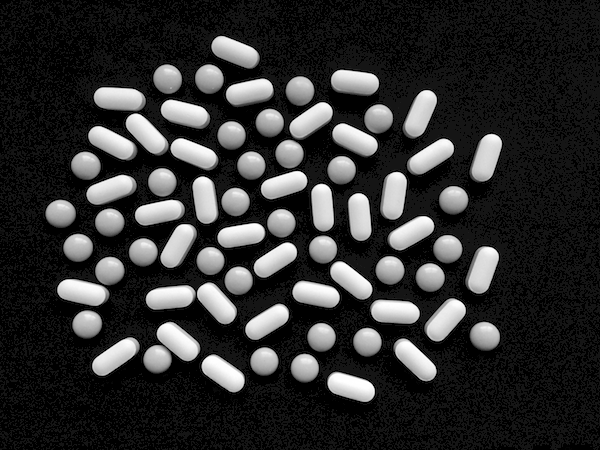

In [33]:
path = "/content/drive/MyDrive/cv/pills.png"
bw_img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
cv2_imshow(bw_img)

In [34]:
#pre-processing
ret1, binary = cv2.threshold(bw_img, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
n = 0

#segmentation
labels = measure.label(binary, n)

#feature Extraction
features = measure.regionprops(labels)

#classification
ellip = 0
round = 0
for feat in features:
    major = feat.major_axis_length
    minor = feat.minor_axis_length
    if minor and major:
        if major/minor > 1.5:
            ellip += 1
        else:
            round += 1
print(f"{ellip} oval pills and {round} round pills in this image")

38 oval pills and 32 round pills in this image
